In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from last weeks notebook(was having trouble excuting the linear regression model because of how many columns encoded dataset was to big so I did not end up using this)

In [2]:
'''housing_feature = pd.read_csv('CRMLS_Preprocessed_FeatureSpecific.csv')

categorical_cols = housing_feature.select_dtypes(include="object").columns

housing_encoded = pd.get_dummies(housing_feature,columns=categorical_cols,drop_first=True)

print(housing_encoded.shape)

X = housing_encoded.drop(columns=["ClosePrice"])
y = housing_encoded["ClosePrice"]

#time base train/test split
latest_month = housing_encoded["DataMonth"].max()

train = housing_encoded[housing_encoded["DataMonth"] < latest_month]
test  = housing_encoded[housing_encoded["DataMonth"] == latest_month]

X_train = train.drop(columns=["ClosePrice"])
y_train = train["ClosePrice"]

X_test = test.drop(columns=["ClosePrice"])
y_test = test["ClosePrice"]

# Remove DataMonth after splitting since it is no longer needed as a predictor
X_train = X_train.drop(columns=["DataMonth"])
X_test = X_test.drop(columns=["DataMonth"])

numeric_features = X_train.select_dtypes(include="number").columns

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])'''

'housing_feature = pd.read_csv(\'CRMLS_Preprocessed_FeatureSpecific.csv\')\n\ncategorical_cols = housing_feature.select_dtypes(include="object").columns\n\nhousing_encoded = pd.get_dummies(housing_feature,columns=categorical_cols,drop_first=True)\n\nprint(housing_encoded.shape)\n\nX = housing_encoded.drop(columns=["ClosePrice"])\ny = housing_encoded["ClosePrice"]\n\n#time base train/test split\nlatest_month = housing_encoded["DataMonth"].max()\n\ntrain = housing_encoded[housing_encoded["DataMonth"] < latest_month]\ntest  = housing_encoded[housing_encoded["DataMonth"] == latest_month]\n\nX_train = train.drop(columns=["ClosePrice"])\ny_train = train["ClosePrice"]\n\nX_test = test.drop(columns=["ClosePrice"])\ny_test = test["ClosePrice"]\n\n# Remove DataMonth after splitting since it is no longer needed as a predictor\nX_train = X_train.drop(columns=["DataMonth"])\nX_test = X_test.drop(columns=["DataMonth"])\n\nnumeric_features = X_train.select_dtypes(include="number").columns\n\nscaler =

In [3]:
housing_feature = pd.read_csv( "CRMLS_Preprocessed_FeatureSpecific.csv")

print("Original shape:", housing_feature.shape)


#removing categorical columns that have too mnay unique values
categorical_cols = housing_feature.select_dtypes(include=["object", "bool"]).columns.tolist()

# needed for train test split
if "DataMonth" in categorical_cols:
    categorical_cols.remove("DataMonth")

high_cardinality_cols = [col for col in categorical_cols if housing_feature[col].nunique(dropna=True) > 100]

print("\nHigh-cardinality columns being dropped:")
print(high_cardinality_cols)

housing_model = housing_feature.drop(columns=high_cardinality_cols,errors="ignore")

#converting remaining categorical vars into dummy variables
categorical_cols = housing_model.select_dtypes(include=["object", "bool"]).columns.tolist()

if "DataMonth" in categorical_cols:
    categorical_cols.remove("DataMonth")

housing_encoded = pd.get_dummies(housing_model,columns=categorical_cols,drop_first=True,dtype="int8")

print("\nEncoded shape:", housing_encoded.shape)


# train test split part
latest_month = housing_encoded["DataMonth"].max()

train = housing_encoded[housing_encoded["DataMonth"] < latest_month].copy()

test = housing_encoded[housing_encoded["DataMonth"] == latest_month].copy()

print("\nLatest test month:", latest_month)
print("Training pool rows:", len(train))
print("Test rows:", len(test))

#only using a sample of the training data to make the basline fast
#while also keeping the full test month
sample_size = min(30000, len(train))

train_sample = train.sample(n=sample_size,random_state=42)

X_train = train_sample.drop(columns=["ClosePrice", "DataMonth"],errors="ignore")

y_train = train_sample["ClosePrice"]

X_test = test.drop(columns=["ClosePrice", "DataMonth"],errors="ignore")

y_test = test["ClosePrice"]

print("\nSampled training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Number of model features:", X_train.shape[1])

#hanfle any reamming inf or missing numeric values if any
numeric_features = X_train.select_dtypes(include=np.number).columns

X_train[numeric_features] = X_train[numeric_features].replace([np.inf, -np.inf],np.nan)

X_test[numeric_features] = X_test[numeric_features].replace([np.inf, -np.inf],np.nan)

for col in numeric_features:
  median_value = X_train[col].median()
  X_train[col] = X_train[col].fillna(median_value)
  X_test[col] = X_test[col].fillna(median_value)


#standar scaler

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


Original shape: (141892, 54)

High-cardinality columns being dropped:
['Flooring', 'CloseDate', 'MLSAreaMajor', 'ElementarySchool', 'BuilderName', 'SubdivisionName', 'City', 'ContractStatusChangeDate', 'ListingContractDate', 'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions', 'HighSchoolDistrict', 'PostalCode']

Encoded shape: (141892, 280)

Latest test month: 202605
Training pool rows: 129875
Test rows: 12017

Sampled training rows: 30000
Testing rows: 12017
Number of model features: 278


Week 4

The linear regression model achieved an R2 of 0.0483 on the test set with an RMSE of approximately 1.64 million

Indicating model explains only a small portion of the variation in home sale prices.

In [14]:
#creating and training model
model = LinearRegression()
model.fit(X_train,y_train)

#model prediction
y_pred = model.predict(X_test)
r2 = r2_score(y_test,y_pred)

print(f"Linear Regression R2: {r2:}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse}\n")

#features using:
print(X_train.shape)

#training rows used
print(f"Training rows used:: {len(X_train)}")

#testing rows used
print(f"\nTesting rows used:: {len(X_test)}")


Linear Regression R2: 0.04828527513685266
RMSE: 1637438.169688876
(30000, 278)
30000 12017


In [6]:
print('B0, the intercept, is: ', model.intercept_)
print('B1, the slope, is: ', model.coef_)
print('The score is: ', model.score(X_test, y_test))

B0, the intercept, is:  1308381.5115926657
B1, the slope, is:  [ 2.94018538e+04 -4.42333962e+05 -4.26237020e+04  7.31720178e+05
  1.10240976e+04 -3.07612121e+03 -1.39184491e+09 -1.37955683e+05
  1.85220300e+05  3.34733347e+05 -1.66241949e+05 -4.90688149e+03
  3.13692551e+04  3.59575845e+04  1.20376625e+04 -9.77632091e+02
  6.15667160e+04  1.39184638e+09  3.61779608e+04  3.87038455e+04
  1.18636939e+04 -9.24809454e+03  2.66506587e+03  1.01249152e+04
 -1.34608160e+04  1.36536242e+04  3.23289265e+04  1.77391542e+04
 -1.30566567e+03  1.52559512e+04  7.59347367e+03 -1.09375569e+04
 -4.04064294e+03 -1.80350639e+04 -9.73561956e+03 -7.48331641e+03
  1.86059594e+04  1.17319280e+04  1.04443778e+05  8.96401230e+02
  4.12942025e+03  7.40111503e+04  4.24657195e+02  1.39596536e+04
  1.88159916e+04 -4.26901398e+04  1.81197525e+04  2.43805187e+04
  4.77898743e+04  1.16466062e+04 -2.07421783e+04 -6.26181297e+05
 -7.79386930e+03  1.41203902e+03  1.70867337e+04  1.64680401e+04
 -3.24884872e+03  5.7720276

The coefficient analysis shows that variables like as LivingArea, BuildingAreaTotal, Latitude, LotSizeSquareFeet, and several location categorical variables had the largest influence on the model's predictions

Some related features like LotSizeSquareFeet and LotSizeAcres have very large coefficients with opposite signs which suggest multicollinearity between highly correlated variables

In [12]:
coef = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_})
coef = coef.sort_values("Coefficient", key=abs, ascending=False)

coef.head(20)

,Feature,Coefficient
17,LotSizeSquareFeet,1.391846e+09
6,LotSizeAcres,-1.391845e+09
105,ListAgentAOR_PacificSouthwest,7.585102e+05
3,LivingArea,7.317202e+05
51,BuyerAgentAOR_PacificSouthwest,-6.261813e+05
167,CountyOrParish_Riverside,-5.712614e+05
151,CountyOrParish_Los Angeles,-5.209657e+05
170,CountyOrParish_San Bernardino,-4.492483e+05
1,Latitude,-4.423340e+05
113,ListAgentAOR_SanDiego,-3.374515e+05


The plot also shows that it struggles to accurately predict higher priced properties

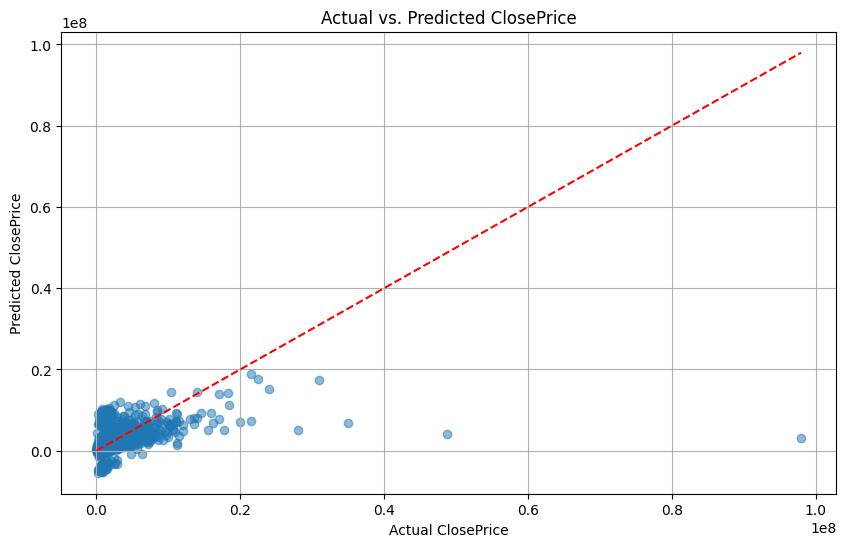

In [11]:
# Plotting actual vs. predicted values for model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs. Predicted ClosePrice")
plt.grid(True)
plt.show()